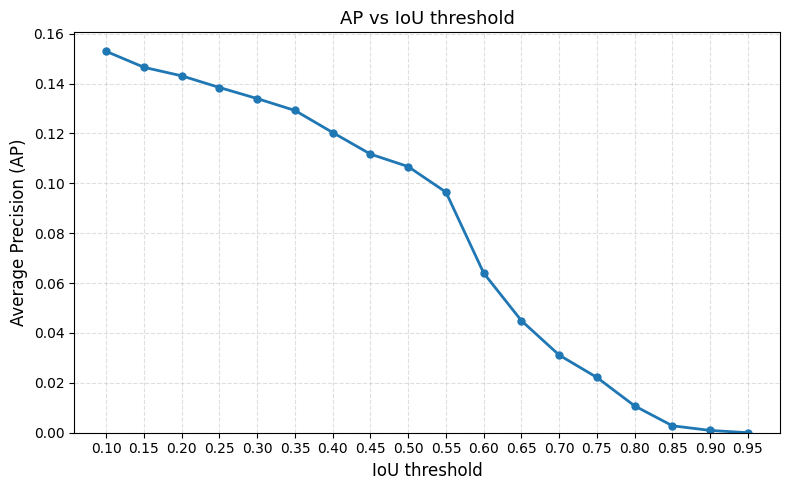

[SAVE] Figure: ap_vs_iou.png


In [1]:
import json
import re
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

METRICS_FILE = "metrics.json"
OUTPUT_FILE = "ap_vs_iou.png"


# ============================================================
# LOAD METRICS
# ============================================================

with open(METRICS_FILE, "r") as f:
    metrics = json.load(f)


# Extract AP@IoU values
iou_values = []
ap_values = []

for key, value in metrics.items():
    match = re.match(r"AP@([0-9.]+)", key)

    if match:
        iou_values.append(float(match.group(1)))
        ap_values.append(float(value))


# Sort by IoU
sorted_values = sorted(zip(iou_values, ap_values))

iou_values = [x[0] for x in sorted_values]
ap_values = [x[1] for x in sorted_values]


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    iou_values,
    ap_values,
    marker="o",
    linewidth=2,
    markersize=5,
)


plt.xlabel("IoU threshold", fontsize=12)
plt.ylabel("Average Precision (AP)", fontsize=12)

plt.title("AP vs IoU threshold", fontsize=13)

plt.xticks(iou_values)
plt.ylim(bottom=0)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"[SAVE] Figure: {OUTPUT_FILE}")